# Quickstart: Broadband Thermal

In this notebook, we'll simulate broadband thermal infrared radiation for a range of surface temperatures. This demonstrates how pyRadtran handles thermal emission — a key component for understanding Earth's energy budget and remote sensing in the infrared.

## Setup

We create a synthetic dataset with 24 time steps at a fixed location (Leipzig, Germany), sweeping the surface temperature from 300 K to 350 K. Each "time step" corresponds to a different surface temperature value.

In [1]:
import pyradtran  # Registers the .pyradtran xarray accessor
from pyradtran import load_config
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from pathlib import Path
import pandas as pd
import logging

# Suppress verbose solver output
logging.getLogger('pyradtran').setLevel(logging.CRITICAL)

# ── Simulation parameters ─────────────────────────────────────────────────────
# Load merged defaults + master config (~/.pyradtran/config.yaml), then customise
cfg = load_config()

# Thermal infrared — broadband integration
cfg.simulation_defaults.rte_solver           = "disort"
cfg.simulation_defaults.mol_abs_param        = "reptran medium"
cfg.simulation_defaults.source               = "thermal"
cfg.simulation_defaults.wavelength_nm        = [3000, 100000]
cfg.simulation_defaults.integrate_wavelength = True

# Output altitudes (1–10 km column)
cfg.simulation_defaults.output_altitudes_km  = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
cfg.simulation_defaults.output_columns       = ["zout", "lambda", "sza", "edir", "eglo", "edn", "eup", "enet", "albedo"]
cfg.simulation_defaults.surface_temperature_k = 248.4

cfg.execution.max_workers        = 16
cfg.execution.cleanup_temp_files = False

config_path = Path("config/thermal_config.yaml")
cfg.to_yaml(config_path)
print(f"Config saved to {config_path}")

# ── Input dataset ─────────────────────────────────────────────────────────────
# 24 time steps, sweeping surface temperature from 300 K → 350 K
N_timesteps = 24

ds = xr.Dataset(
    coords={
        'time':      pd.date_range('2025-04-04T12:00:00', periods=N_timesteps, freq='s'),
        'latitude':  ('time', [51.34] * N_timesteps),
        'longitude': ('time', [12.37] * N_timesteps),
    },
    data_vars={
        'surface_temperature': ('time', np.linspace(300, 350, N_timesteps)),
    }
)

# ── Run ───────────────────────────────────────────────────────────────────────
ds_sim = ds.pyradtran.run(
    config_path=config_path,
    surface_temperature_var='surface_temperature',
    show_progress=False,
)

print("Simulation complete!")
print(f"Variables: {list(ds_sim.data_vars.keys())}")
print(f"Dimensions: {dict(ds_sim.dims)}")

2026-04-19 01:25:47,133 - pyradtran.config - INFO - Configuration written to config/thermal_config.yaml


Config saved to config/thermal_config.yaml
Simulation complete!
Variables: ['zout', 'lambda', 'sza', 'edir', 'eglo', 'edn', 'eup', 'enet', 'albedo']
Dimensions: {'time': 24, 'altitude': 10}


/tmp/ipykernel_17284/1340688361.py:60: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f"Dimensions: {dict(ds_sim.dims)}")


In [2]:
# Attach the surface temperature to the output dataset for plotting
ds_sim['surface_temperature'] = ds['surface_temperature']

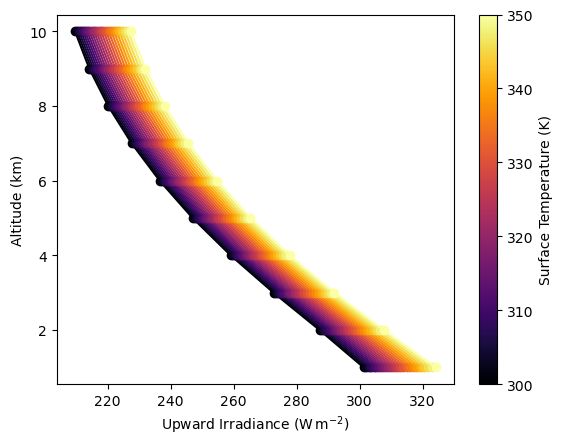

In [5]:
fig, ax = plt.subplots()

### change the prop cycle to inferno colors

ax.set_prop_cycle(color=plt.cm.inferno(np.linspace(0, 1, len(ds_sim['eup'].time))))

ds_sim['eup'].plot(ax=ax, hue='time', add_legend=False, marker='o', linestyle='-', label='EUP', y='altitude')
ax.set_xlabel(r'Upward Irradiance (W$\,$m$^{-2}$)')
ax.set_ylabel('Altitude (km)')

### add a colorbar instead of a legend

norm = plt.Normalize(ds_sim['surface_temperature'].min(), ds_sim['surface_temperature'].max())
sm = plt.cm.ScalarMappable(cmap=plt.cm.inferno, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, label='Surface Temperature (K)')
